In [ ]:
import pandas as pd

df = pd.read_csv('/content/ML_Features_2025.csv')

df.head()

,Diversification_Score,Local_Dependency,State,Visitors_2025,YoY_Growth_2025,Population_2025,Tourism_Intensity
0,42.530510,75.22%,Sabah,22361.16800,8.592517,3754.5,5.955831
1,55.756208,65.22%,Sarawak,22721.52700,15.775225,2528.9,8.984747
2,77.798562,5.74%,Pulau Pinang,17717.97900,6.703940,1804.3,9.819863
3,79.279950,2.08%,Melaka,20832.20153,8.907154,1052.0,19.802473
4,80.100728,34.84%,Johor,18196.97300,6.176999,4204.1,4.328387


In [ ]:
# Check column names
print(df.columns)

# Convert Local_Dependency from text like "75.22%" to numeric
df['Local_Dependency'] = (
    df['Local_Dependency']
    .str.replace('%', '', regex=False)
    .astype(float)
)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Preview cleaned data
df.head()

Index(['Diversification_Score', 'Local_Dependency', 'State', 'Visitors_2025',
       'YoY_Growth_2025', 'Population_2025', 'Tourism_Intensity'],
      dtype='object')

Missing values:
Diversification_Score    0
Local_Dependency         0
State                    0
Visitors_2025            0
YoY_Growth_2025          0
Population_2025          0
Tourism_Intensity        0
dtype: int64


,Diversification_Score,Local_Dependency,State,Visitors_2025,YoY_Growth_2025,Population_2025,Tourism_Intensity
0,42.530510,75.22,Sabah,22361.16800,8.592517,3754.5,5.955831
1,55.756208,65.22,Sarawak,22721.52700,15.775225,2528.9,8.984747
2,77.798562,5.74,Pulau Pinang,17717.97900,6.703940,1804.3,9.819863
3,79.279950,2.08,Melaka,20832.20153,8.907154,1052.0,19.802473
4,80.100728,34.84,Johor,18196.97300,6.176999,4204.1,4.328387


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features for K-Means
features = [
    'Visitors_2025',
    'YoY_Growth_2025',
    'Local_Dependency',
    'Diversification_Score',
    'Tourism_Intensity'
]

X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check scaled data
print(X_scaled[:5])

[[ 0.43538435 -0.57554169  2.60895315 -2.99372569 -0.8993938 ]
 [ 0.47245667  0.26734607  2.14428737 -1.9444308  -0.3830286 ]
 [-0.04228876 -0.79716539 -0.61954469 -0.19564375 -0.24065924]
 [ 0.27809026 -0.53861912 -0.78961237 -0.07811399  1.46116157]
 [ 0.00698827 -0.85900165  0.73263273 -0.0129954  -1.17683806]]


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

print("K | Inertia | Silhouette Score")
for k, inertia, score in zip(k_values, inertias, silhouette_scores):
    print(f"{k} | {inertia:.2f} | {score:.3f}")

K | Inertia | Silhouette Score
2 | 51.69 | 0.451
3 | 34.21 | 0.367
4 | 24.96 | 0.366
5 | 19.76 | 0.223
6 | 13.73 | 0.204


In [ ]:
from sklearn.cluster import KMeans

for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'Cluster_{k}'] = model.fit_predict(X_scaled)

print(df[['State', 'Cluster_2', 'Cluster_3', 'Cluster_4']].sort_values('State'))

                State  Cluster_2  Cluster_3  Cluster_4
4               Johor          0          0          1
10              Kedah          0          0          1
12           Kelantan          0          0          1
3              Melaka          0          0          1
5     Negeri Sembilan          0          0          1
9              Pahang          0          0          1
7               Perak          0          0          1
6              Perlis          0          2          0
2        Pulau Pinang          0          0          1
0               Sabah          1          1          2
1             Sarawak          1          1          2
11           Selangor          0          0          1
13         Terengganu          0          0          1
14  W.P. Kuala Lumpur          0          0          3
8         W.P. Labuan          0          2          0
15     W.P. Putrajaya          0          2          0


In [ ]:
features_to_compare = [
    'Visitors_2025',
    'YoY_Growth_2025',
    'Local_Dependency',
    'Diversification_Score',
    'Tourism_Intensity'
]

print("=== K = 3 ===")
display(
    df.groupby('Cluster_3')[features_to_compare]
      .mean()
      .round(2)
)

print("\n=== K = 4 ===")
display(
    df.groupby('Cluster_4')[features_to_compare]
      .mean()
      .round(2)
)

=== K = 3 ===


,Visitors_2025,YoY_Growth_2025,Local_Dependency,Diversification_Score,Tourism_Intensity
Cluster_3,,,,,
0,21588.68,10.70,14.69,84.36,10.91
1,22541.35,12.18,70.22,49.14,7.47
2,2502.18,24.64,1.03,86.00,14.90



=== K = 4 ===


,Visitors_2025,YoY_Growth_2025,Local_Dependency,Diversification_Score,Tourism_Intensity
Cluster_4,,,,,
0,2502.18,24.64,1.03,86.00,14.90
1,20241.55,8.77,15.59,83.82,10.32
2,22541.35,12.18,70.22,49.14,7.47
3,35059.93,29.93,5.74,89.73,16.89


In [ ]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = final_kmeans.fit_predict(X_scaled)

df[['State', 'Cluster']].sort_values('Cluster')

,State,Cluster
3,Melaka,0
2,Pulau Pinang,0
5,Negeri Sembilan,0
4,Johor,0
7,Perak,0
11,Selangor,0
10,Kedah,0
9,Pahang,0
14,W.P. Kuala Lumpur,0
13,Terengganu,0


In [ ]:
cluster_names = {
    0: 'Established & Diversified Tourism Markets',
    1: 'Locally Dependent Tourism Markets',
    2: 'Emerging High-Growth Markets'
}

df['Cluster_Label'] = df['Cluster'].map(cluster_names)

df[
    [
        'State',
        'Visitors_2025',
        'YoY_Growth_2025',
        'Local_Dependency',
        'Diversification_Score',
        'Tourism_Intensity',
        'Cluster',
        'Cluster_Label'
    ]
].sort_values('Cluster')

,State,Visitors_2025,YoY_Growth_2025,Local_Dependency,Diversification_Score,Tourism_Intensity,Cluster,Cluster_Label
3,Melaka,20832.201530,8.907154,2.08,79.279950,19.802473,0,Established & Diversified Tourism Markets
2,Pulau Pinang,17717.979000,6.703940,5.74,77.798562,9.819863,0,Established & Diversified Tourism Markets
5,Negeri Sembilan,19356.545000,8.839215,7.04,81.119298,15.561175,0,Established & Diversified Tourism Markets
4,Johor,18196.973000,6.176999,34.84,80.100728,4.328387,0,Established & Diversified Tourism Markets
7,Perak,23642.055000,8.568238,15.28,83.055175,9.185661,0,Established & Diversified Tourism Markets
11,Selangor,36376.442000,5.558816,22.92,87.962372,4.909963,0,Established & Diversified Tourism Markets
10,Kedah,15607.884000,6.527638,17.32,86.563984,7.008165,0,Established & Diversified Tourism Markets
9,Pahang,23161.166000,14.807715,23.54,85.101475,13.812718,0,Established & Diversified Tourism Markets
14,W.P. Kuala Lumpur,35059.933182,29.933621,5.74,89.730468,16.894725,0,Established & Diversified Tourism Markets
13,Terengganu,15462.278000,6.926000,13.12,88.849454,12.411525,0,Established & Diversified Tourism Markets


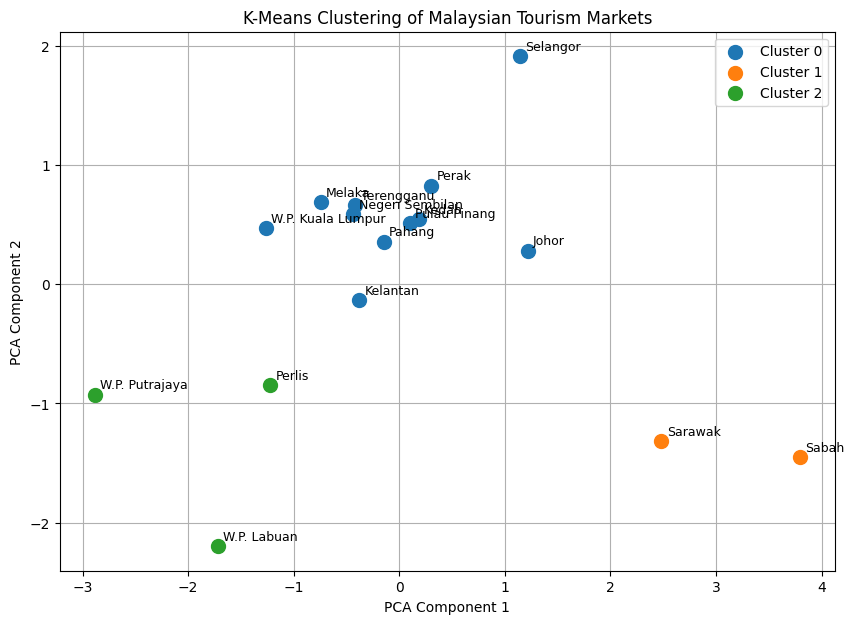

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    plt.scatter(
        subset['PCA1'],
        subset['PCA2'],
        label=f'Cluster {cluster}',
        s=100
    )

    for _, row in subset.iterrows():
        plt.text(
            row['PCA1'] + 0.05,
            row['PCA2'] + 0.05,
            row['State'],
            fontsize=9
        )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Malaysian Tourism Markets')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
strategy_map = {
    0: 'Sustain & Optimize',
    1: 'Diversify Source Markets',
    2: 'Promote & Develop Capacity'
}

df['Recommended_Strategy'] = df['Cluster'].map(strategy_map)

df[
    [
        'State',
        'Cluster',
        'Cluster_Label',
        'Recommended_Strategy'
    ]
].sort_values(['Cluster', 'State'])

,State,Cluster,Cluster_Label,Recommended_Strategy
4,Johor,0,Established & Diversified Tourism Markets,Sustain & Optimize
10,Kedah,0,Established & Diversified Tourism Markets,Sustain & Optimize
12,Kelantan,0,Established & Diversified Tourism Markets,Sustain & Optimize
3,Melaka,0,Established & Diversified Tourism Markets,Sustain & Optimize
5,Negeri Sembilan,0,Established & Diversified Tourism Markets,Sustain & Optimize
9,Pahang,0,Established & Diversified Tourism Markets,Sustain & Optimize
7,Perak,0,Established & Diversified Tourism Markets,Sustain & Optimize
2,Pulau Pinang,0,Established & Diversified Tourism Markets,Sustain & Optimize
11,Selangor,0,Established & Diversified Tourism Markets,Sustain & Optimize
13,Terengganu,0,Established & Diversified Tourism Markets,Sustain & Optimize


In [ ]:
output_cols = [
    'State',
    'Visitors_2025',
    'YoY_Growth_2025',
    'Local_Dependency',
    'Diversification_Score',
    'Tourism_Intensity',
    'Cluster',
    'Cluster_Label',
    'Recommended_Strategy'
]

df[output_cols].to_csv(
    '/content/NADI_ML_Cluster_Output.csv',
    index=False
)

print("CSV exported successfully.")

CSV exported successfully.
